# MobiAct / MobiFall Dataset — Format Explorer

This notebook walks through the raw structure of the **MobiAct** dataset (the updated release of MobiFall): how files are organised, what the columns mean, and where the accelerometer, gyroscope, and orientation signals live.

**Reference:** Vavoulas et al. (2016). *The MobiAct Dataset: Recognition of Activities of Daily Living using Smartphones.*  
ICT4AWE 2016. Also: Vavoulas et al. (2014). *The MobiFall Dataset: Fall Detection and Classification with a Smartphone.*

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

MOBIFALL_PATH = 'MobiFall_dataset'
ANN_PATH = os.path.join(MOBIFALL_PATH, 'Annotated Data')
RAW_PATH = os.path.join(MOBIFALL_PATH, 'Raw Data')

print('Dataset root:', os.path.abspath(MOBIFALL_PATH))
print('Annotated :', os.path.abspath(ANN_PATH))
print('Raw       :', os.path.abspath(RAW_PATH))

Dataset root: /home/ubuntu/git/FD-CNN/MobiFall_dataset
Annotated : /home/ubuntu/git/FD-CNN/MobiFall_dataset/Annotated Data
Raw       : /home/ubuntu/git/FD-CNN/MobiFall_dataset/Raw Data


---
## 1. Directory structure

Unlike SisFall (organised by *subject*), MobiAct is organised by **activity code**.  
Each activity has its own sub-folder under both `Annotated Data/` and `Raw Data/`.

| Category | Codes |
|----------|-------|
| Falls | `FOL`, `FKL`, `BSC`, `SDL` |
| ADLs  | `STD`, `WAL`, `JOG`, `JUM`, `STU`, `STN`, `SCH`, `SIT`, `CHU`, `CSI`, `CSO`, `LYI` |
| Scenarios | `SLH`, `SBW`, `SLW`, `SBE`, `SRH` |

In [16]:
FALL_CODES = {'FOL', 'FKL', 'BSC', 'SDL'}
SCENARIO_CODES = {'SLH', 'SBW', 'SLW', 'SBE', 'SRH'}

activity_dirs = sorted(d for d in os.listdir(ANN_PATH)
                       if os.path.isdir(os.path.join(ANN_PATH, d)))

falls     = [c for c in activity_dirs if c in FALL_CODES]
adls      = [c for c in activity_dirs if c not in FALL_CODES and c not in SCENARIO_CODES]
scenarios = [c for c in activity_dirs if c in SCENARIO_CODES]

print(f'Total activity directories : {len(activity_dirs)}')
print(f'Falls     ({len(falls):2d}) : {falls}')
print(f'ADLs      ({len(adls):2d}) : {adls}')
print(f'Scenarios ({len(scenarios):2d}) : {scenarios}')

Total activity directories : 20
Falls     ( 4) : ['BSC', 'FKL', 'FOL', 'SDL']
ADLs      (11) : ['CHU', 'CSI', 'CSO', 'JOG', 'JUM', 'SCH', 'SIT', 'STD', 'STN', 'STU', 'WAL']
Scenarios ( 5) : ['SBE', 'SBW', 'SLH', 'SLW', 'SRH']


---
## 2. File-name convention

### Annotated data
```
<ACTIVITY_CODE>_<SUBJECT_ID>_<TRIAL_NO>_annotated.csv
```

### Raw data
```
<ACTIVITY_CODE>_<SENSOR_CODE>_<SUBJECT_ID>_<TRIAL_NO>.txt
```

| Part | Example | Meaning |
|------|---------|---------|
| Activity code | `FKL` | Fall front-knees-lying |
| Activity code | `WAL` | Walking |
| Sensor code   | `acc` / `gyro` / `ori` | Accelerometer / Gyroscope / Orientation |
| Subject ID    | `5` | Participant number 5 |
| Trial         | `2` | 2nd repetition |

**Note:** The annotated CSVs already merge all sensors into one file with a `label` column per row.

In [17]:
examples = [
    ('Annotated', 'FKL_5_2_annotated.csv'),
    ('Annotated', 'WAL_1_1_annotated.csv'),
    ('Raw',       'FKL_acc_5_2.txt'),
    ('Raw',       'WAL_gyro_1_1.txt'),
]

print(f"{'Kind':<12} {'Filename':<35} {'Code':<6} {'Sensor':<8} {'Subject':<9} {'Trial'}")
print('-' * 82)
for kind, fname in examples:
    parts = fname.replace('_annotated.csv','').replace('.txt','').split('_')
    if kind == 'Annotated':
        code, subj, trial = parts[0], parts[1], parts[2]
        sensor = '(merged)'
    else:
        code, sensor, subj, trial = parts[0], parts[1], parts[2], parts[3]
    print(f'{kind:<12} {fname:<35} {code:<6} {sensor:<8} {subj:<9} {trial}')

Kind         Filename                            Code   Sensor   Subject   Trial
----------------------------------------------------------------------------------
Annotated    FKL_5_2_annotated.csv               FKL    (merged) 5         2
Annotated    WAL_1_1_annotated.csv               WAL    (merged) 1         1
Raw          FKL_acc_5_2.txt                     FKL    acc      5         2
Raw          WAL_gyro_1_1.txt                    WAL    gyro     1         1


---
## 3. Activity types — descriptions and participant coverage

**66 subjects** participated, but not every subject performed every activity.

| Code | Activity | Trials per subject | Duration | Description |
|------|----------|--------------------|----------|-------------|
| **Falls** ||||
| `FOL` | Forward-lying | 3 | 10 s | Fall forward from standing, hands dampen impact |
| `FKL` | Front-knees-lying | 3 | 10 s | Fall forward from standing, first impact on knees |
| `BSC` | Back-sitting-chair | 3 | 10 s | Fall backward while trying to sit on a chair |
| `SDL` | Sideward-lying | 3 | 10 s | Fall sidewards from standing, bending legs |
| **ADLs** ||||
| `STD` | Standing | 1 | 5 min | Standing with subtle movements |
| `WAL` | Walking | 1 | 5 min | Normal walking |
| `JOG` | Jogging | 3 | 30 s | Jogging |
| `JUM` | Jumping | 3 | 30 s | Continuous jumping |
| `STU` | Stairs up | 6 | 10 s | Stairs up (10 stairs) |
| `STN` | Stairs down | 6 | 10 s | Stairs down (10 stairs) |
| `SCH` | Stand to sit | 6 | 6 s | Transition from standing to sitting on a chair |
| `SIT` | Sitting | 1 | 1 min | Sitting on a chair with subtle movements |
| `CHU` | Sit to stand | 6 | 6 s | Transition from sitting to standing |
| `CSI` | Car-step in | 6 | 6 s | Step into a car |
| `CSO` | Car-step out | 6 | 6 s | Step out of a car |
| `LYI` | Lying | — | — | Inactivity period after a fall (embedded in fall files) |

---
## 4. Activity types — file and sample counts

For every activity code the table below shows:
- **Files** — total number of annotated `.csv` recordings
- **Subjects** — unique participants
- **Total samples** — sum of all rows across files (at 200 Hz)
- **Avg duration (s)** — mean recording length per file

Rows highlighted in **dark red** are falls; **dark blue** are ADLs; **dark teal** are scenarios; **dark purple** is the total row.

In [18]:
ACTIVITY_DESC = {
    # Falls
    'FOL': 'Forward-lying fall',
    'FKL': 'Front-knees-lying fall',
    'BSC': 'Back-sitting-chair fall',
    'SDL': 'Sideward-lying fall',
    # ADLs
    'STD': 'Standing',
    'WAL': 'Walking',
    'JOG': 'Jogging',
    'JUM': 'Jumping',
    'STU': 'Stairs up',
    'STN': 'Stairs down',
    'SCH': 'Stand to sit (on chair)',
    'SIT': 'Sitting on chair',
    'CHU': 'Sit to stand (chair up)',
    'CSI': 'Car-step in',
    'CSO': 'Car-step out',
    # Scenarios
    'SLH': 'Scenario – Leaving the home',
    'SBW': 'Scenario – Being at work',
    'SLW': 'Scenario – Leaving work',
    'SBE': 'Scenario – Being exercise',
    'SRH': 'Scenario – Returning at home',
}

def activity_type(code):
    if code in FALL_CODES:
        return 'Fall'
    if code in SCENARIO_CODES:
        return 'Scenario'
    return 'ADL'

file_counts   = defaultdict(int)
sample_counts = defaultdict(int)
subject_sets  = defaultdict(set)

for code in activity_dirs:
    code_path = os.path.join(ANN_PATH, code)
    for fname in os.listdir(code_path):
        if not fname.endswith('.csv'):
            continue
        parts = fname.replace('_annotated.csv', '').split('_')
        subj = parts[1]
        subject_sets[code].add(subj)
        file_counts[code] += 1
        with open(os.path.join(code_path, fname)) as fh:
            n = sum(1 for line in fh if ',' in line) - 1  # subtract header
        sample_counts[code] += n

rows = []
for code in sorted(ACTIVITY_DESC):
    if code not in file_counts:
        continue
    n_files   = file_counts[code]
    n_samples = sample_counts[code]
    rows.append({
        'Code':             code,
        'Type':             activity_type(code),
        'Description':      ACTIVITY_DESC[code],
        'Subjects':         len(subject_sets[code]),
        'Files':            n_files,
        'Total samples':    n_samples,
        'Avg duration (s)': round(n_samples / n_files / 200, 1),
    })

summary_df = pd.DataFrame(rows)

totals = pd.DataFrame([{
    'Code': '—',
    'Type': '—',
    'Description': 'TOTAL',
    'Subjects': '—',
    'Files': summary_df['Files'].sum(),
    'Total samples': summary_df['Total samples'].sum(),
    'Avg duration (s)': round(
        summary_df['Total samples'].sum() / summary_df['Files'].sum() / 200, 1
    ),
}])
display_df = pd.concat([summary_df, totals], ignore_index=True)

_FALL_STYLE     = 'background-color: #922b21; color: white'
_ADL_STYLE      = 'background-color: #1a5276; color: white'
_SCENARIO_STYLE = 'background-color: #0e6655; color: white'
_TOTAL_STYLE    = 'background-color: #4a235a; color: white'

def _row_style(row):
    if row['Description'] == 'TOTAL':
        return [_TOTAL_STYLE] * len(row)
    if row['Type'] == 'Fall':
        return [_FALL_STYLE] * len(row)
    if row['Type'] == 'Scenario':
        return [_SCENARIO_STYLE] * len(row)
    return [_ADL_STYLE] * len(row)

styled = (
    display_df.style
    .apply(_row_style, axis=1)
    .format({'Total samples': '{:,}', 'Files': '{:,}'})
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_caption('MobiAct activity types — file and sample counts (200 Hz)')
)
display(styled)

fall_files  = summary_df[summary_df['Type'] == 'Fall']['Files'].sum()
adl_files   = summary_df[summary_df['Type'] == 'ADL']['Files'].sum()
scen_files  = summary_df[summary_df['Type'] == 'Scenario']['Files'].sum()
print(f'\nFall  recordings : {fall_files:,}  ({len(summary_df[summary_df["Type"]=="Fall"])} types)')
print(f'ADL   recordings : {adl_files:,}  ({len(summary_df[summary_df["Type"]=="ADL"])} types)')
print(f'Scenario files   : {scen_files:,}  ({len(summary_df[summary_df["Type"]=="Scenario"])} types)')
print(f'Total            : {fall_files + adl_files + scen_files:,}')

,Code,Type,Description,Subjects,Files,Total samples,Avg duration (s)
0,BSC,Fall,Back-sitting-chair fall,64,191,"373,755",9.800000
1,CHU,ADL,Sit to stand (chair up),19,114,"129,477",5.700000
2,CSI,ADL,Car-step in,60,358,"408,730",5.700000
3,CSO,ADL,Car-step out,60,360,"410,571",5.700000
4,FKL,Fall,Front-knees-lying fall,64,192,"375,726",9.800000
5,FOL,Fall,Forward-lying fall,64,192,"374,684",9.800000
6,JOG,ADL,Jogging,61,183,"1,086,142",29.700000
7,JUM,ADL,Jumping,61,183,"1,086,073",29.700000
8,SBE,Scenario,Scenario – Being exercise,19,19,"453,768",119.400000
9,SBW,Scenario,Scenario – Being at work,19,19,"680,809",179.200000



Fall  recordings : 767  (4 types)
ADL   recordings : 2,432  (11 types)
Scenario files   : 95  (5 types)
Total            : 3,294


---
## 5. Annotated CSV format — 12 columns

Each annotated `.csv` file is sampled at **200 Hz** and already in **physical units** (no ADC counts to convert).

| Column | Sensor | Signal | Unit |
|--------|--------|--------|------|
| `timestamp` | — | Absolute time | nanoseconds |
| `rel_time` | — | Time since recording start | seconds |
| `acc_x` | Accelerometer | Acceleration X (incl. gravity) | m/s² |
| `acc_y` | Accelerometer | Acceleration Y (incl. gravity) | m/s² |
| `acc_z` | Accelerometer | Acceleration Z (incl. gravity) | m/s² |
| `gyro_x` | Gyroscope | Angular velocity X | rad/s |
| `gyro_y` | Gyroscope | Angular velocity Y | rad/s |
| `gyro_z` | Gyroscope | Angular velocity Z | rad/s |
| `azimuth` | Orientation | Rotation around Z-axis | degrees |
| `pitch` | Orientation | Rotation around X-axis | degrees |
| `roll` | Orientation | Rotation around Y-axis | degrees |
| `label` | — | Activity label for this sample | string |

**Important:** Fall files contain **multiple labels per recording** — the pre-fall phase (`STD`), the actual fall (`FKL`, `FOL`, etc.), and the post-fall lying period (`LYI`).

**Gravity:** At rest, the magnitude `√(acc_x² + acc_y² + acc_z²) ≈ 9.81 m/s²`.

In [19]:
def load_mobifall(filepath):
    """Read a MobiAct annotated CSV."""
    return pd.read_csv(filepath)


df_adl  = load_mobifall(os.path.join(ANN_PATH, 'WAL', 'WAL_1_1_annotated.csv'))
df_fall = load_mobifall(os.path.join(ANN_PATH, 'FKL', 'FKL_1_1_annotated.csv'))

print(f'ADL  (WAL_1_1) : {len(df_adl):>6} rows × {df_adl.shape[1]} cols  = {len(df_adl)/200:.0f} s @ 200 Hz')
print(f'Fall (FKL_1_1) : {len(df_fall):>6} rows × {df_fall.shape[1]} cols  = {len(df_fall)/200:.1f} s @ 200 Hz')
print()
print('Columns:', list(df_fall.columns))
print()
print('FKL_1_1 — per-row label counts:')
print(df_fall['label'].value_counts().to_string())

ADL  (WAL_1_1) :  59771 rows × 12 cols  = 299 s @ 200 Hz
Fall (FKL_1_1) :   1979 rows × 12 cols  = 9.9 s @ 200 Hz

Columns: ['timestamp', 'rel_time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'azimuth', 'pitch', 'roll', 'label']

FKL_1_1 — per-row label counts:
label
LYI    1073
FKL     500
STD     406


---
## 6. DataFrame head — first rows in physical units

In [20]:
print('=== ADL: Walking (WAL_1_1) — first 6 rows ===')
display(df_adl.head(6).round(4))

print('\n=== Fall: Front-knees-lying (FKL_1_1) — first 6 rows ===')
display(df_fall.head(6).round(4))

=== ADL: Walking (WAL_1_1) — first 6 rows ===


,timestamp,rel_time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,azimuth,pitch,roll,label
0,2037407391000,0.0000,-1.1079,10.3262,-1.6777,-0.0144,-0.9511,-0.2175,294.8589,-103.5388,0.5164,STD
1,2037412380000,0.0050,-1.2297,10.2843,-1.7082,-0.1017,-0.9062,-0.1713,294.9713,-103.5604,0.5165,STD
2,2037417406000,0.0100,-1.3525,10.2420,-1.7389,-0.2010,-0.8714,-0.1222,295.0708,-103.5597,0.5265,STD
3,2037423909000,0.0165,-1.5113,10.1873,-1.7787,-0.2938,-0.7923,-0.0067,295.1515,-103.5376,0.5731,STD
4,2037427390000,0.0200,-1.5963,10.1580,-1.8000,-0.3793,-0.7340,0.0382,295.2253,-103.4900,0.6137,STD
5,2037432417000,0.0250,-1.7190,10.1157,-1.8307,-0.3778,-0.5800,0.1063,295.2585,-103.4443,0.7029,STD



=== Fall: Front-knees-lying (FKL_1_1) — first 6 rows ===


,timestamp,rel_time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,azimuth,pitch,roll,label
0,2022659688000,0.0000,0.6504,-9.5678,-1.2335,-1.1240,0.5247,0.0993,171.2194,28.2617,33.0317,STD
1,2022664717000,0.0050,0.6489,-9.5688,-1.2304,-1.0052,0.4484,0.0864,170.9081,29.1276,32.7820,STD
2,2022669735000,0.0100,0.6475,-9.5697,-1.2273,-0.8668,0.3763,0.0889,170.5849,29.9763,32.5424,STD
3,2022674702000,0.0150,0.6461,-9.5707,-1.2242,-0.7303,0.3228,0.0800,170.2614,30.7951,32.3157,STD
4,2022679693000,0.0200,0.6446,-9.5716,-1.2211,-0.6115,0.1307,0.0388,169.9064,31.5818,32.1375,STD
5,2022685519000,0.0258,0.6429,-9.5727,-1.2175,-0.2443,-0.0455,0.0021,169.5475,32.2819,31.9636,STD


---
## 7. Verify sample rate and gravity magnitude

In [21]:
# Sample rate from rel_time diffs
dt = df_adl['rel_time'].diff().dropna()
fs = 1.0 / dt.median()
print(f'Median sample interval : {dt.median()*1000:.2f} ms')
print(f'Inferred sample rate   : {fs:.1f} Hz')
print()

# Gravity magnitude at rest (WAL is dynamic, use quiet STD-labelled rows of a fall file)
df_std = load_mobifall(os.path.join(ANN_PATH, 'STD', 'STD_1_1_annotated.csv'))
df_std['acc_mag'] = np.sqrt(df_std['acc_x']**2 + df_std['acc_y']**2 + df_std['acc_z']**2)
print(f'Gravity check (STD_1_1):')
print(f'  Mean |acc|  = {df_std["acc_mag"].mean():.4f} m/s²  (expected ≈ 9.81)')
print(f'  Std  |acc|  = {df_std["acc_mag"].std():.4f} m/s²')

Median sample interval : 5.00 ms
Inferred sample rate   : 200.1 Hz

Gravity check (STD_1_1):
  Mean |acc|  = 9.7523 m/s²  (expected ≈ 9.81)
  Std  |acc|  = 0.0721 m/s²


---
## 8. Subject demographics

66 participants in the dataset, all young adults (ages 20–47).

In [22]:
# Subject metadata from the dataset README
SUBJECTS = [
    (1,32,180,85,'M'),(2,26,169,64,'M'),(3,26,164,55,'F'),(4,32,186,93,'M'),
    (5,36,160,50,'F'),(6,22,172,62,'F'),(7,25,189,80,'M'),(8,22,183,93,'M'),
    (9,30,177,102,'M'),(10,26,170,90,'F'),(11,26,168,80,'F'),(12,29,178,83,'M'),
    (13,24,177,62,'M'),(14,24,178,85,'M'),(15,25,173,82,'M'),(16,27,172,56,'F'),
    (17,25,173,67,'M'),(18,25,176,73,'M'),(19,25,161,63,'F'),(20,26,178,71,'M'),
    (21,25,180,70,'M'),(22,22,187,90,'M'),(23,23,171,64,'M'),(24,21,193,112,'M'),
    (25,22,170,62,'F'),(26,25,163,60,'F'),(27,25,180,82,'M'),(28,23,178,70,'M'),
    (29,27,186,103,'M'),(30,47,172,90,'M'),(31,27,170,75,'M'),(32,25,190,77,'M'),
    (33,27,171,70,'M'),(34,24,175,85,'M'),(35,23,181,76,'M'),(36,22,164,62,'F'),
    (37,25,172,63,'M'),(38,21,170,88,'F'),(39,26,174,79,'M'),(40,23,178,95,'M'),
    (41,20,172,67,'F'),(42,22,173,73,'M'),(43,24,179,80,'M'),(44,25,176,80,'M'),
    (45,26,175,92,'M'),(46,23,175,68,'F'),(47,21,180,85,'M'),(48,22,180,80,'M'),
    (49,23,178,75,'M'),(50,23,165,50,'F'),(51,23,171,70,'M'),(52,20,179,79,'M'),
    (53,27,186,120,'M'),(54,27,164,55,'F'),(55,28,178,78,'M'),(56,29,170,75,'M'),
    (57,21,187,70,'M'),(58,21,158,58,'F'),(59,26,175,70,'M'),(60,24,183,107,'M'),
    (61,24,170,70,'M'),(62,20,180,70,'M'),(63,24,187,85,'M'),(64,26,181,70,'M'),
    (65,40,170,100,'M'),(66,20,193,83,'M'),(67,23,180,67,'M'),
]

subj_df = pd.DataFrame(SUBJECTS, columns=['ID','Age','Height_cm','Weight_kg','Gender'])

print(f"Total subjects : {len(subj_df)}")
print(f"Age   : {subj_df['Age'].min()}–{subj_df['Age'].max()} years  (mean {subj_df['Age'].mean():.1f})")
print(f"Height: {subj_df['Height_cm'].min()}–{subj_df['Height_cm'].max()} cm    (mean {subj_df['Height_cm'].mean():.1f})")
print(f"Weight: {subj_df['Weight_kg'].min()}–{subj_df['Weight_kg'].max()} kg    (mean {subj_df['Weight_kg'].mean():.1f})")
print()
print(subj_df['Gender'].value_counts().rename_axis('Gender').reset_index(name='Count').to_string(index=False))

Total subjects : 67
Age   : 20–47 years  (mean 25.2)
Height: 158–193 cm    (mean 175.7)
Weight: 50–120 kg    (mean 76.8)

Gender  Count
     M     51
     F     16


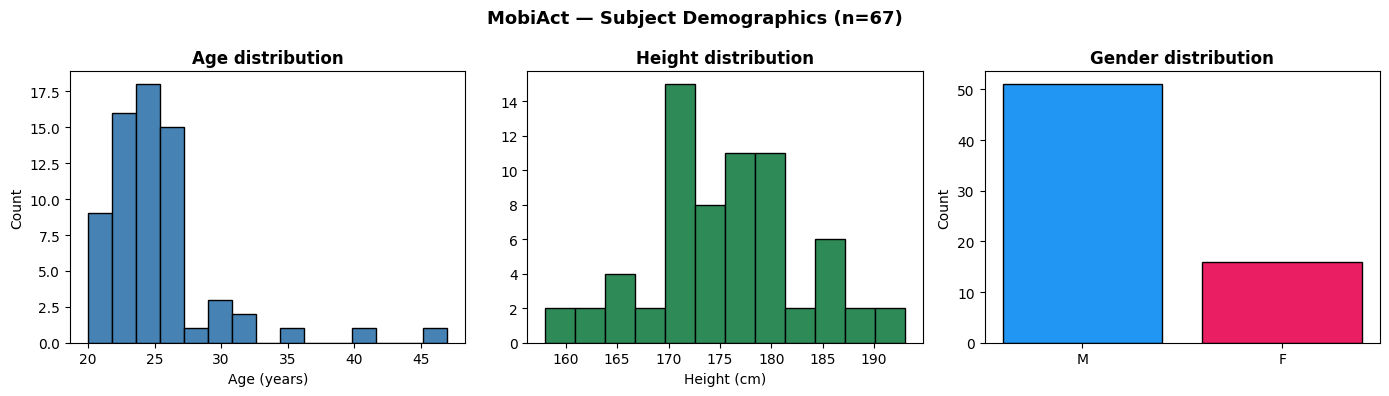

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(subj_df['Age'], bins=15, edgecolor='black', color='steelblue')
axes[0].set_title('Age distribution', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

axes[1].hist(subj_df['Height_cm'], bins=12, edgecolor='black', color='seagreen')
axes[1].set_title('Height distribution', fontweight='bold')
axes[1].set_xlabel('Height (cm)')

counts = subj_df['Gender'].value_counts()
axes[2].bar(counts.index, counts.values, edgecolor='black', color=['#2196F3','#E91E63'])
axes[2].set_title('Gender distribution', fontweight='bold')
axes[2].set_ylabel('Count')

fig.suptitle('MobiAct — Subject Demographics (n=67)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Raw time-series — Walking vs. Fall (all 9 sensor channels)

Plotting a 5-second window of WAL and the full FKL fall recording for subject 1.

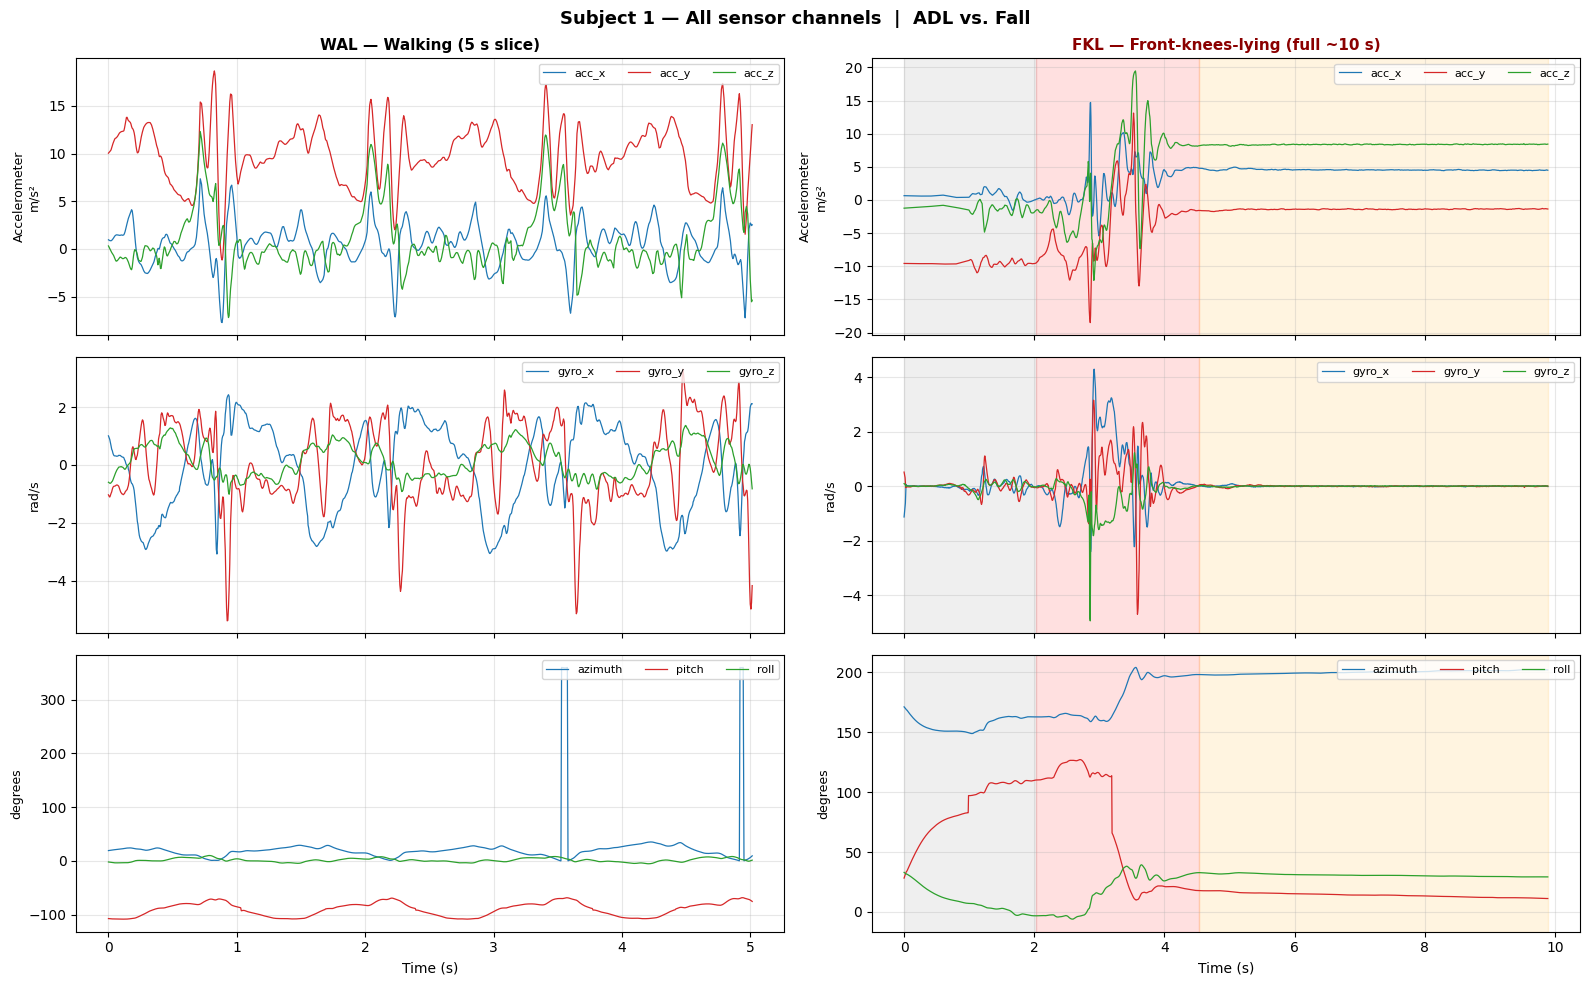

In [24]:
t_adl  = df_adl['rel_time'].values
t_fall = df_fall['rel_time'].values

# 5-second window from the middle of the walking recording
mid = len(df_adl) // 2
w   = 5 * 200  # 5 s at 200 Hz
adl_slice = df_adl.iloc[mid:mid+w]
t_slice   = adl_slice['rel_time'].values - adl_slice['rel_time'].values[0]

sensor_groups = [
    ('Accelerometer', ['acc_x', 'acc_y', 'acc_z'], 'm/s²'),
    ('Gyroscope',     ['gyro_x', 'gyro_y', 'gyro_z'], 'rad/s'),
    ('Orientation',   ['azimuth', 'pitch', 'roll'], 'degrees'),
]

axis_colors = ['#1f77b4', '#d62728', '#2ca02c']

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex='col')

for row_i, (title, cols, unit) in enumerate(sensor_groups):
    for col_i, (t, df, label) in enumerate([
        (t_slice, adl_slice, 'WAL — Walking (5 s slice)'),
        (t_fall,  df_fall,   'FKL — Front-knees-lying (full ~10 s)'),
    ]):
        ax = axes[row_i][col_i]
        for colname, color in zip(cols, axis_colors):
            ax.plot(t, df[colname].values, color=color, linewidth=0.9,
                    label=colname)
        ax.set_ylabel(unit, fontsize=9)
        ax.legend(loc='upper right', fontsize=8, ncol=3)
        ax.grid(True, alpha=0.3)
        if row_i == 0:
            ax.set_title(label, fontsize=11, fontweight='bold',
                         color='darkred' if 'FKL' in label else 'black')
        if row_i == 0:
            ax.set_ylabel(f'{title}\n{unit}', fontsize=9)
        else:
            ax.set_ylabel(unit, fontsize=9)

axes[-1][0].set_xlabel('Time (s)', fontsize=10)
axes[-1][1].set_xlabel('Time (s)', fontsize=10)

# Annotate fall phases on the FKL plots
phase_colors = {'STD': 'grey', 'FKL': 'red', 'LYI': 'orange'}
for row_i in range(3):
    ax = axes[row_i][1]
    prev_label = df_fall['label'].iloc[0]
    start_t    = t_fall[0]
    for i, (t_i, lbl) in enumerate(zip(t_fall, df_fall['label'])):
        if lbl != prev_label or i == len(t_fall) - 1:
            ax.axvspan(start_t, t_i, alpha=0.12,
                       color=phase_colors.get(prev_label, 'blue'),
                       label=f'Phase: {prev_label}')
            start_t    = t_i
            prev_label = lbl

fig.suptitle('Subject 1 — All sensor channels  |  ADL vs. Fall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Fall phases — label timeline for FKL_1_1

Each fall recording has three phases labelled per-row:
1. **Pre-fall** — subject standing/performing the setup activity (grey)
2. **Fall** — the actual fall event (red)
3. **LYI** — lying quietly on the floor after the fall (orange)

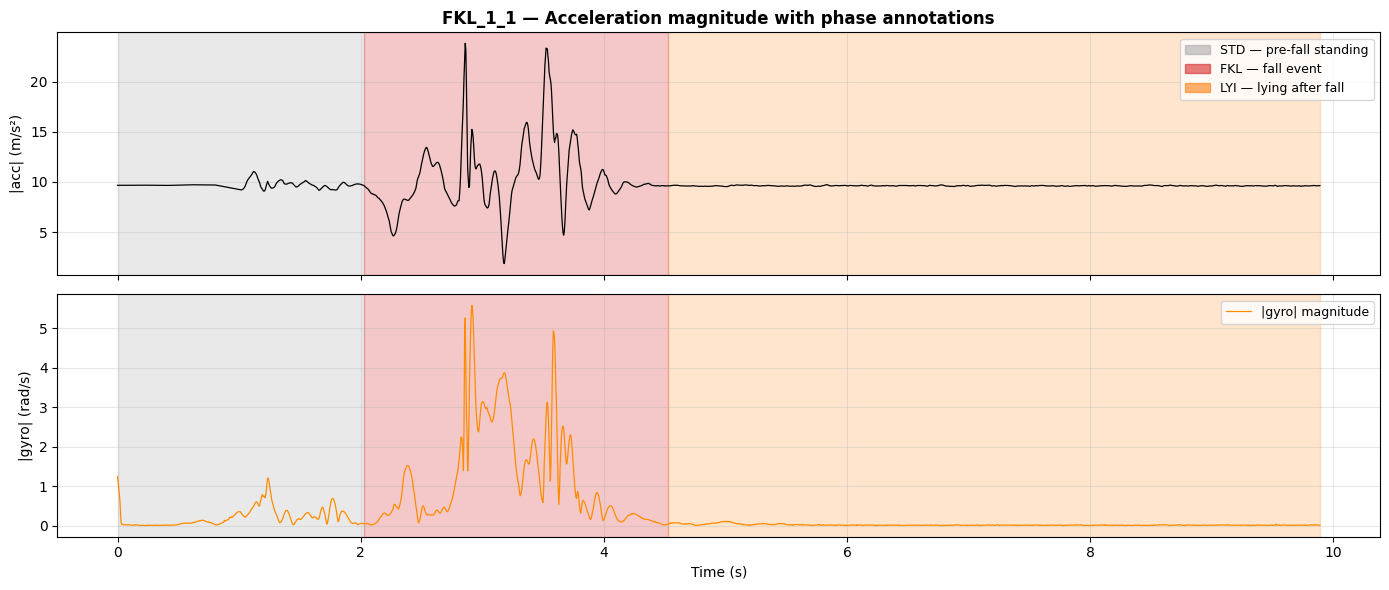

Phase durations:
  FKL   :  500 samples = 2.50 s
  LYI   : 1073 samples = 5.37 s
  STD   :  406 samples = 2.03 s


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Accelerometer magnitude
df_fall['acc_mag'] = np.sqrt(df_fall['acc_x']**2 + df_fall['acc_y']**2 + df_fall['acc_z']**2)
axes[0].plot(t_fall, df_fall['acc_mag'], color='black', linewidth=0.9, label='|acc| magnitude')
axes[0].set_ylabel('|acc| (m/s²)')
axes[0].set_title('FKL_1_1 — Acceleration magnitude with phase annotations', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Gyroscope magnitude
df_fall['gyro_mag'] = np.sqrt(df_fall['gyro_x']**2 + df_fall['gyro_y']**2 + df_fall['gyro_z']**2)
axes[1].plot(t_fall, df_fall['gyro_mag'], color='darkorange', linewidth=0.9, label='|gyro| magnitude')
axes[1].set_ylabel('|gyro| (rad/s)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Shade fall phases on both axes
phase_colors = {'STD': ('#aaaaaa', 0.25), 'FKL': ('#d62728', 0.25), 'LYI': ('#ff7f0e', 0.20)}

for ax in axes:
    prev_label = df_fall['label'].iloc[0]
    start_t    = t_fall[0]
    for i, (t_i, lbl) in enumerate(zip(t_fall[1:], df_fall['label'].iloc[1:]), start=1):
        if lbl != prev_label:
            color, alpha = phase_colors.get(prev_label, ('#888888', 0.2))
            ax.axvspan(start_t, t_fall[i-1], alpha=alpha, color=color)
            start_t    = t_fall[i-1]
            prev_label = lbl
    color, alpha = phase_colors.get(prev_label, ('#888888', 0.2))
    ax.axvspan(start_t, t_fall[-1], alpha=alpha, color=color)

# Legend for phases
legend_patches = [
    mpatches.Patch(color='#aaaaaa', alpha=0.6, label='STD — pre-fall standing'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='FKL — fall event'),
    mpatches.Patch(color='#ff7f0e', alpha=0.6, label='LYI — lying after fall'),
]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print('Phase durations:')
for lbl, grp in df_fall.groupby('label'):
    print(f'  {lbl:6s}: {len(grp):4d} samples = {len(grp)/200:.2f} s')

---
## 11. ADL vs. Fall — accelerometer comparison

Walking (5 s) vs. each of the four fall types for subject 1, showing the accelerometer X/Y/Z axes.

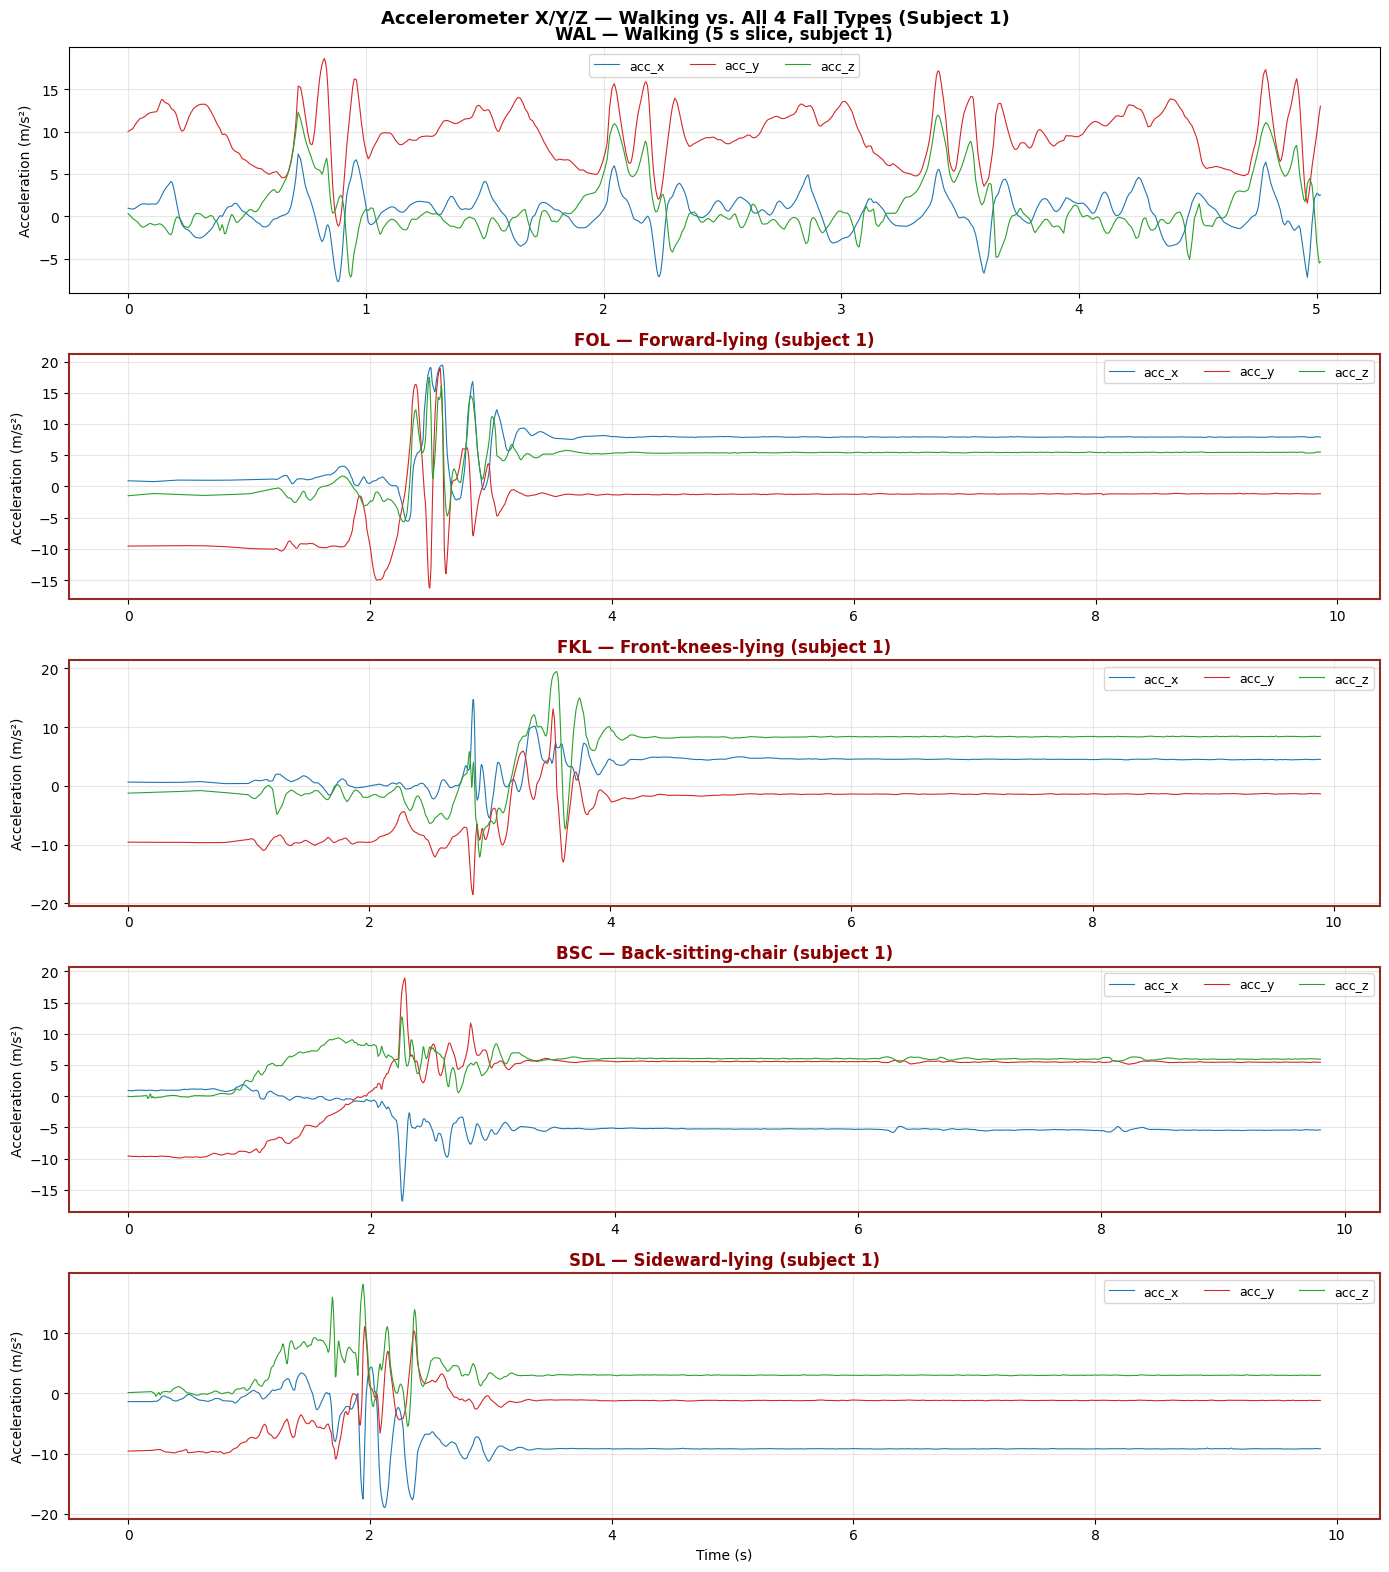

In [26]:
fall_codes_ordered = ['FOL', 'FKL', 'BSC', 'SDL']
fall_labels = {
    'FOL': 'Forward-lying',
    'FKL': 'Front-knees-lying',
    'BSC': 'Back-sitting-chair',
    'SDL': 'Sideward-lying',
}

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)

axis_colors = ['#1f77b4', '#d62728', '#2ca02c']
acc_cols    = ['acc_x', 'acc_y', 'acc_z']

# Walking slice
ax = axes[0]
for col, color in zip(acc_cols, axis_colors):
    ax.plot(t_slice, adl_slice[col].values, color=color, linewidth=0.8, label=col)
ax.set_title('WAL — Walking (5 s slice, subject 1)', fontweight='bold')
ax.set_ylabel('Acceleration (m/s²)')
ax.legend(ncol=3, fontsize=9)
ax.grid(True, alpha=0.3)

# Four fall types
for ax, code in zip(axes[1:], fall_codes_ordered):
    fpath = os.path.join(ANN_PATH, code, f'{code}_1_1_annotated.csv')
    if not os.path.exists(fpath):
        # fall back to first available file
        files = sorted(os.listdir(os.path.join(ANN_PATH, code)))
        fpath = os.path.join(ANN_PATH, code, files[0])
    df_f = load_mobifall(fpath)
    t_f  = df_f['rel_time'].values
    for col, color in zip(acc_cols, axis_colors):
        ax.plot(t_f, df_f[col].values, color=color, linewidth=0.8, label=col)
    ax.set_title(f'{code} — {fall_labels[code]} (subject 1)', fontweight='bold', color='darkred')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(ncol=3, fontsize=9)
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('#922b21')
        spine.set_linewidth(1.5)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Accelerometer X/Y/Z — Walking vs. All 4 Fall Types (Subject 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Cross-participant comparison — mean accelerometer magnitude during walking

For each subject that has a WAL recording, compute the mean and std of `|acc|` over the full walk.

In [27]:
records = []
wal_dir = os.path.join(ANN_PATH, 'WAL')
for fname in sorted(os.listdir(wal_dir)):
    if not fname.endswith('.csv'):
        continue
    parts = fname.replace('_annotated.csv', '').split('_')
    subj  = int(parts[1])
    df    = load_mobifall(os.path.join(wal_dir, fname))
    mag   = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    records.append({
        'subject':   subj,
        'n_samples': len(df),
        'duration_s': len(df) / 200,
        'acc_mag_mean': mag.mean(),
        'acc_mag_std':  mag.std(),
        'acc_x_mean': df['acc_x'].mean(),
        'acc_y_mean': df['acc_y'].mean(),
        'acc_z_mean': df['acc_z'].mean(),
    })

wal_df = pd.DataFrame(records).sort_values('subject')
print(f'WAL recordings loaded: {len(wal_df)}')
print(f'Mean acc magnitude: {wal_df["acc_mag_mean"].mean():.3f} m/s²  '
      f'(expected ≈ 9.81 at rest, higher during walking)')
print()
print(wal_df[['subject','n_samples','duration_s',
              'acc_mag_mean','acc_mag_std']].round(2).head(10).to_string(index=False))

WAL recordings loaded: 61
Mean acc magnitude: 10.599 m/s²  (expected ≈ 9.81 at rest, higher during walking)

 subject  n_samples  duration_s  acc_mag_mean  acc_mag_std
       1      59771      298.86         10.55         3.50
       2      59989      299.94         10.60         2.34
       3      59973      299.86         10.41         2.74
       4      59981      299.90         10.59         4.04
       5      59993      299.96         10.18         2.68
       6      59895      299.48         10.45         3.18
       7      59975      299.88         10.48         3.56
       8      59993      299.96         10.51         3.42
       9      59999      300.00         11.40         3.67
      10      59960      299.80         10.77         3.61


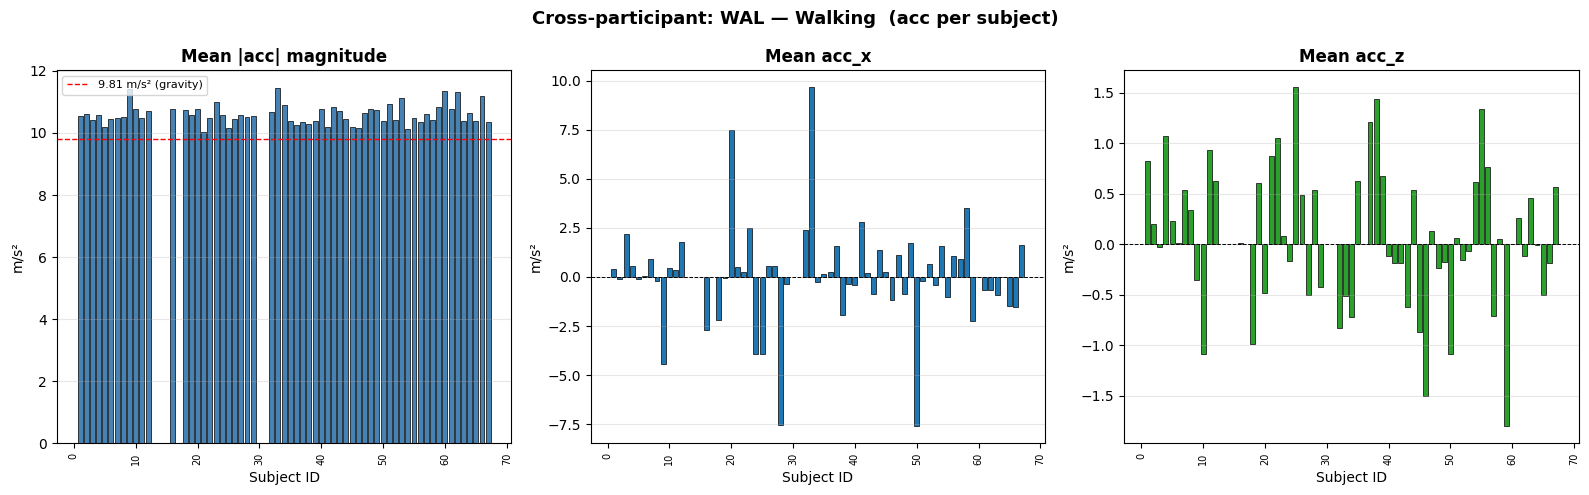

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_kw = dict(edgecolor='black', linewidth=0.5)

# |acc| magnitude
axes[0].bar(wal_df['subject'], wal_df['acc_mag_mean'], color='steelblue', **bar_kw)
axes[0].axhline(9.81, color='red', linestyle='--', linewidth=1, label='9.81 m/s² (gravity)')
axes[0].set_title('Mean |acc| magnitude', fontweight='bold')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('m/s²')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Per-axis means
for ax, col, color, title in [
    (axes[1], 'acc_x_mean', '#1f77b4', 'Mean acc_x'),
    (axes[2], 'acc_z_mean', '#2ca02c', 'Mean acc_z'),
]:
    ax.bar(wal_df['subject'], wal_df[col], color=color, **bar_kw)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('m/s²')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=90, labelsize=7)

fig.suptitle('Cross-participant: WAL — Walking  (acc per subject)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Summary — column map cheat sheet

```
Annotated CSV column  →  Sensor         →  Signal                →  Unit
────────────────────────────────────────────────────────────────────────────
timestamp             →  —              →  Absolute time          →  ns
rel_time              →  —              →  Time since start        →  s
acc_x                 →  Accelerometer  →  Accel X (incl. gravity) →  m/s²
acc_y                 →  Accelerometer  →  Accel Y (incl. gravity) →  m/s²
acc_z                 →  Accelerometer  →  Accel Z (incl. gravity) →  m/s²
gyro_x                →  Gyroscope      →  Angular velocity X      →  rad/s
gyro_y                →  Gyroscope      →  Angular velocity Y      →  rad/s
gyro_z                →  Gyroscope      →  Angular velocity Z      →  rad/s
azimuth               →  Orientation    →  Rotation around Z-axis  →  degrees
pitch                 →  Orientation    →  Rotation around X-axis  →  degrees
roll                  →  Orientation    →  Rotation around Y-axis  →  degrees
label                 →  Annotation     →  Activity at this sample →  string
────────────────────────────────────────────────────────────────────────────
Sample rate : 200 Hz  |  Device: smartphone (hip/thigh)
Units       : already in physical units — no ADC conversion needed
```

### Key differences from SisFall

| | SisFall | MobiAct |
|--|---------|--------|
| File organisation | By **subject** | By **activity code** |
| Units | Raw ADC counts (need conversion) | Physical units (m/s², rad/s, degrees) |
| Sensors | 2× accelerometers + 1× gyroscope | 1× accelerometer + 1× gyroscope + orientation |
| Labels | Encoded in filename | Per-row `label` column |
| Fall files | Fall only | Pre-fall + Fall + LYI (multi-phase) |
| Subjects | 38 (young + elderly) | 67 (young adults only) |
| Fall types | 15 | 4 |
| ADL types | 19 | 11 (+ 5 scenarios) |